# 학습 데이터 클래스 분포 분석

이 노트북은 `data/raw/train.csv` 를 불러와 클래스 분포를 확인하고 시각화합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
from pathlib import Path

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
train_path = None
for base in candidates:
    candidate = base / "data/raw/train.csv"
    if candidate.exists():
        train_path = candidate
        break

if train_path is None:
    raise FileNotFoundError("train.csv not found in expected locations")

print(f"Using train.csv from: {train_path}")

df = pd.read_csv(train_path)
df.head()

Using train.csv from: /root/Computer_vision/data/raw/train.csv


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


In [3]:
class_counts = df["target"].value_counts().sort_index()
class_counts

target
0     100
1      46
2     100
3     104
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13     81
14     50
15    100
16    100
Name: count, dtype: int64

/tmp/ipykernel_25291/101311449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


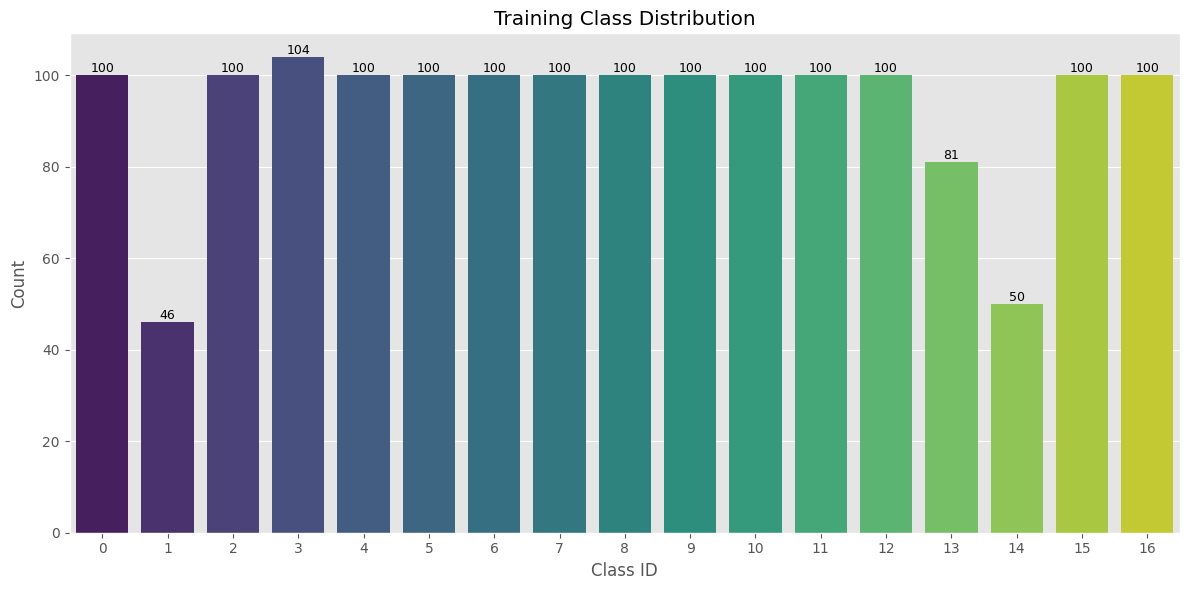

In [4]:
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.title("Training Class Distribution")
for idx, value in enumerate(class_counts.values):
    plt.text(idx, value, str(value), ha="center", va="bottom", fontsize=9)
plt.tight_layout()

> 위 그래프는 각 클래스별 샘플 수를 나타냅니다. 데이터 증강이나 샘플링 전략을 세울 때 참고하세요.